## FFNN

In [61]:
import numpy as np
from ids_expt.data.dataset import (
    DataSetConfig,
    SamplingMethod,
    CLFDataSet as DataSet,
    DFDataSet,
)
from ids_expt.models.trainer import NNTrainer, NNTrainerConfig
from pathlib import Path
from loguru import logger
import pandas as pd
from sklearn.preprocessing import StandardScaler
from ids_expt.core.defs import TOP_CIC_FEATURES
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier
from pathlib import Path
import torch
from ids_expt.models.ffnn import FFNN
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score, AUROC


model_path = Path(
    r"C:\Users\Viper\Desktop\thesis_code\results\cic_fnn\ctgan_oversampling\best_model.pth"
)


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):

        return self.model(x)[0]


train_dataset, val_dataset = DFDataSet(
    config=DataSetConfig(
        csv_path=Path(r"E:\MSc Works\IDS\data\cicflow_combined.csv"),
        features=TOP_CIC_FEATURES,
        sampling_method=SamplingMethod.NONE,
        max_data=-1,
        train_ratio=0.8,
    )
).get_datasets()

model = FFNN(
    input_size=len(TOP_CIC_FEATURES),
    hidden_layers=[90] * 9,
    output_size=val_dataset.data.Label.nunique(),
    use_batchnorm=False,
)
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
model = ClfModel(model)
model.eval()

train_df = pd.read_csv(r"E:\MSc Works\IDS\cic_merged_train_data.csv")
train_df.columns = train_df.columns.str.strip()
val_df = pd.read_csv(r"E:\MSc Works\IDS\cic_merged_test_data.csv")
val_df.columns = val_df.columns.str.strip()
X_train = train_df.drop(columns=["Label"])
y_train = train_df["Label"]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = val_df.drop(columns=["Label"])
y_val = val_df["Label"]
X_val = scaler.transform(X_val)
train_dataset.data = pd.DataFrame(X_train, columns=train_df.columns[:-1])
train_dataset.data["Label"] = y_train.values
val_dataset.data = pd.DataFrame(X_val, columns=val_df.columns[:-1])
val_dataset.data["Label"] = y_val.values

f1_score = F1Score(task="multiclass", num_classes=val_dataset.data.Label.nunique())

x_test = X_val.astype(np.float32).reshape(
    len(X_val), 1, len(TOP_CIC_FEATURES)
)  # Reshape for PyTorch input
y_test = np.array([val_dataset.label_encoding[label] for label in y_val]).astype(
    np.float32
)

c:\Users\Viper\Desktop\thesis_code\venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:628: UserWarning: <built-in function callable> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-06-30 14:07:29.079 | INFO     | ids_expt.data.dataset:get_datasets:92 - Label counts in the dataset: {'NORMAL': 14705, 'DISABLE_UNSOLICITED': 5760, 'COLD_RESTART': 5760, 'WARM_RESTART': 5760, 'DNP3_ENUMERATE': 3368, 'DNP3_INFO': 3340, 'ARP_POISONING': 835, 'INIT_DATA': 720, 'STOP_APP': 720, 'REPLAY': 666, 'MITM_DOS': 130}
2025-06-30 14:07:29.129 | INFO     | ids_expt.data.dataset:get_datasets:108 - Training dataset sampled with label counts: {'NORMAL': 11764, 'DISABLE_UNSOLICITED': 4608, 'COLD_RESTART': 4608, 'WARM_RESTART': 4608, 'DNP3_ENUMERATE': 2694, 'DNP3_INFO': 2672, 'ARP_

## Model's F1

In [62]:
logits = model(torch.tensor(x_test)).squeeze(1)
probs = torch.softmax(logits, dim=1)
labels = torch.tensor(y_test, dtype=torch.float32)
orig_predictions = torch.argmax(probs, dim=1)
f1_score(orig_predictions, labels.argmax(dim=1))

tensor(0.9357)

## Adversarial F1

In [66]:
x_min, x_max = X_train.min(axis=0), X_train.max(axis=0)
clip_values = (x_min, x_max)
classifier = PyTorchClassifier(
    model=model,
    clip_values=clip_values,
    loss=torch.nn.CrossEntropyLoss(),  # Specify the loss function if needed
    input_shape=len(TOP_CIC_FEATURES),  # Adjust based on your input shape
    nb_classes=val_dataset.data.Label.nunique(),
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
)
# Step 6: Generate adversarial test examples
attack = FastGradientMethod(estimator=classifier, eps=1)
x_test_adv = attack.generate(x=x_test)

# Step 7: Evaluate the ART classifier on adversarial test examples
adv_predictions = classifier.predict(x_test_adv)

In [67]:
prediction = torch.nn.functional.softmax(
    torch.from_numpy(adv_predictions.reshape(-1, val_dataset.data.Label.nunique()))
)
f1_score(prediction.argmax(dim=1), labels.argmax(dim=1))

C:\Users\Viper\AppData\Local\Temp\ipykernel_12816\2354818302.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(


tensor(0.8906)

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

Mean Absolute Deviation: 0.000015


TypeError: only length-1 arrays can be converted to Python scalars

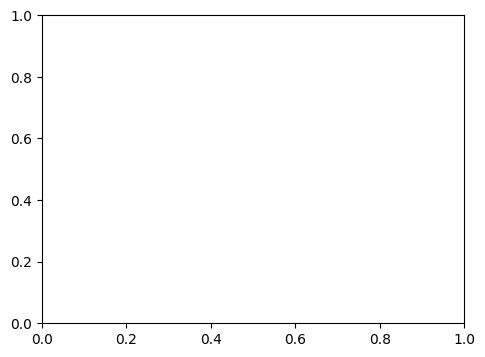

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean absolute deviation
mad = np.abs(x_test_adv - x_test).mean()
print(f"Mean Absolute Deviation: {mad:.6f}")

# Visualize sample differences
sample_idx = 0
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.bar(range(len(TOP_CIC_FEATURES)), x_test[sample_idx])
plt.title("Original Features")
plt.subplot(122)
plt.bar(range(len(TOP_CIC_FEATURES)), x_test_adv[sample_idx] - x_test[sample_idx])
plt.title("Adversarial Perturbation")
plt.show()

## Image Clf

In [16]:
from ids_expt.models.cnn import CNN2D as SimpleCNN, BiggerCNN2D
from ids_expt.data.session_image_dataset import (
    SessionImageDataConfig,
    DFDataSet,
    TorchImageDataset,
    SamplingMethod,
)
from pathlib import Path
from loguru import logger
import torch
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score, AUROC

config = SessionImageDataConfig(
    max_data=-100,
    session_images_dir=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\session_images"
    ),
    labels_file=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\labelled_sessions.csv"
    ),
    sampling_method=SamplingMethod.OVERSAMPLE,
)
train_ds, test_ds = DFDataSet(config=config).load_data()

model = BiggerCNN2D(
    in_channel=1,
    num_classes=len(train_ds.label_encoding),
    dropout_rate=0.1,
).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model.load_state_dict(
    torch.load(
        Path(
            r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\bigger_cnn2d\best_model.pth"
        ),
        map_location=torch.device("cuda"),
    )
)

2025-06-30 11:09:52.025 | INFO     | ids_expt.data.session_image_dataset:load_data:119 - Data loaded into DataFrame with 32960 entries
2025-06-30 11:09:52.028 | INFO     | ids_expt.data.session_image_dataset:load_data:120 - Label distribution:
label
NORMAL                 13761
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
INIT_DATA                692
STOP_APP                 680
REPLAY                   547
Name: count, dtype: int64
2025-06-30 11:09:52.029 | INFO     | ids_expt.data.session_image_dataset:load_data:125 - Final dataset size: 32960 entries after applying max_data limit
2025-06-30 11:09:52.072 | INFO     | ids_expt.data.session_image_dataset:load_data:154 - Oversampling to 10321 samples per class for training
2025-06-30 11:09:52.188 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Split data into 72247 training and 8240 testing samples
2025-06-30 11:09:52.189 | INFO     | ids_expt.data.session_image_dataset:load_dat

<All keys matched successfully>

In [53]:
from tqdm import tqdm

testds = TorchImageDataset(test_ds)
test_loader = torch.utils.data.DataLoader(
    testds,
    batch_size=32,
    shuffle=False,
)
f1_score = F1Score(task="multiclass", num_classes=len(test_ds.label_encoding))

predictions = []
targets = []

for images, labels in tqdm(test_loader):
    images = images.to(torch.float32)
    logits, proba = model(images.to("cuda"))
    preds = torch.argmax(proba, dim=1)
    predictions.extend(preds.cpu().numpy())
    targets.extend(labels.argmax(dim=1).cpu().numpy())

100%|██████████| 258/258 [00:19<00:00, 12.98it/s]


In [ ]:
f1 = f1_score(torch.tensor(predictions), torch.tensor(targets))
print(f"F1 Score: {f1:.4f}")

In [60]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):

        return self.model(x)[0]


test_loader = torch.utils.data.DataLoader(
    testds,
    batch_size=64,
    shuffle=False,
)
x_min, x_max = (0, 1)
clip_values = (x_min, x_max)
classifier = PyTorchClassifier(
    model=ClfModel(model),
    clip_values=clip_values,
    loss=torch.nn.CrossEntropyLoss(),
    input_shape=(1, 6 * 32, 8 * 32),
    nb_classes=test_ds.data_df.label.nunique(),
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
)

attack = FastGradientMethod(estimator=classifier, eps=0.01)
adv_predictions = []
targets = []
for images, labels in tqdm(test_loader):
    adv_images = attack.generate(x=images.numpy())
    adv_preds = classifier.predict(adv_images)
    adv_preds = torch.nn.functional.softmax(
        torch.from_numpy(adv_preds.reshape(-1, test_ds.data_df.label.nunique()))
    )
    adv_predictions.extend(adv_preds.argmax(axis=1))
    targets.extend(labels.argmax(dim=1).numpy())
f1_score = F1Score(task="multiclass", num_classes=test_ds.data_df.label.nunique())
f1 = f1_score(torch.tensor(adv_predictions), torch.tensor(targets))
print(f"F1 Score on Adversarial Examples: {f1:.4f}")

  0%|          | 0/129 [00:00<?, ?it/s]C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\3423322273.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  adv_preds = torch.nn.functional.softmax(
100%|██████████| 129/129 [01:52<00:00,  1.14it/s]

F1 Score on Adversarial Examples: 0.2387


In [55]:
preds = torch.nn.functional.softmax(
    torch.from_numpy(adv_predictions.reshape(-1, test_ds.data_df.label.nunique()))
)
f1_score = F1Score(task="multiclass", num_classes=len(test_ds.label_encoding))
score = f1_score(preds.argmax(dim=1), torch.tensor(labels.argmax(dim=1)))
print(f"F1 Score on Adversarial Examples: {score:.4f}")

F1 Score on Adversarial Examples: 0.2500


C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\851724519.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  preds = torch.nn.functional.softmax(
C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\851724519.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = f1_score(preds.argmax(dim=1), torch.tensor(labels.argmax(dim=1)))


In [52]:
torch.tensor(targets).shape

torch.Size([8240])

## Adversarial Testing

In [78]:
from art.attacks.evasion.projected_gradient_descent.projected_gradient_descent import (
    ProjectedGradientDescent,
)
from loguru import logger
from art.estimators.classification import PyTorchClassifier
from ids_expt.utils.confusion_matrix import get_confusion_matrix
from torchmetrics import F1Score
from pathlib import Path
from ids_expt.data.session_image_dataset import (
    SessionImageDataConfig,
    DFDataSet,
    TorchImageDataset,
    SamplingMethod,
)
import cv2
import numpy as np


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)[0]


class AdversarialExperiment:
    def __init__(
        self,
        model: torch.nn.Module,
        model_name: str,
        attacks: list[ProjectedGradientDescent],
        train_dataset: TorchImageDataset,
        test_dataset: TorchImageDataset,
        input_shape=(1, 6 * 32, 8 * 32),
        loss=torch.nn.CrossEntropyLoss(),
        clip_values=(0, 1),
        optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
        output_dir: Path = Path(
            r"C:\Users\Viper\Desktop\thesis_code\results\adversarial_experiment"
        ),
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
    ):
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.model = model
        self.attacks = attacks
        self.input_shape = input_shape
        self.classifier = PyTorchClassifier(
            model=model,
            loss=loss,
            clip_values=clip_values,
            input_shape=input_shape,
            nb_classes=train_dataset.data.label.nunique(),
            optimizer=optimizer,
        )
        self.f1_score = F1Score(
            task="multiclass", num_classes=train_dataset.data.label.nunique()
        )
        self.output_dir = output_dir / model_name
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def run(self):
        for attack in self.attacks:
            logger.info(f"Running attack: {attack.__class__.__name__}")
            adv_predictions = []
            targets = []
            for images, labels in tqdm(
                torch.utils.data.DataLoader(
                    self.test_dataset, batch_size=64, shuffle=False
                )
            ):
                images = images.to(torch.float32)
                adv_images = attack.generate(x=images.numpy())
                adv_logits, adv_proba = self.model(torch.tensor(adv_images).to("cuda"))
                adv_preds = torch.argmax(adv_proba, dim=1)
                adv_predictions.extend(adv_preds.cpu().numpy())
                targets.extend(labels.argmax(dim=1).cpu().numpy())
            f1 = self.f1_score(torch.tensor(adv_predictions), torch.tensor(targets))
            logger.info(f"F1 Score on Adversarial Examples: {f1:.4f}")
            eps= attack.eps
            cm = get_confusion_matrix(
                adv_predictions,
                targets,
                self.train_dataset.label_encoding,
                out_file=self.output_dir / f"{attack.__class__.__name__}_{eps}.png",
            )
            logger.info(f"Confusion Matrix:\n{cm}")
        
    def _generate(self, attack, out_folder, dataset,preserve_blank_areas=False):
        num_samples = len(dataset)
        if not (self.output_dir / out_folder).exists():
            (self.output_dir / out_folder).mkdir(parents=True, exist_ok=True)
        logger.info(f"Generating adversarial examples for {num_samples} samples")
        for sample_idx in tqdm(range(num_samples), desc="Generating adversarial examples"):
            row = dataset.dataset.data_df.iloc[sample_idx]
            # arr, arr, str
            image, label, label_str = dataset.dataset[sample_idx]
            adv_img = attack.generate(
                x=image.reshape(1, *self.input_shape).astype(np.float32)
            )
            adv_img = adv_img.reshape(self.input_shape[1:])
            # reverse normalize
            adv_img = adv_img * 255
            adv_img = adv_img.astype(np.uint8)
            # write to file
            filename = Path(row["file_path"]).name
            adv_img_path = self.output_dir / out_folder / filename
            if preserve_blank_areas:
                row_mask = np.all(image == 0, axis=1)
                col_mask = np.all(image == 0, axis=0)

                # Apply masks to adversarial image
                adv_img[row_mask, :] = 0
                adv_img[:, col_mask] = 0
            cv2.imwrite(str(adv_img_path), adv_img)

        logger.info('Done')

    def generate(
        self,
        attack: ProjectedGradientDescent,
        out_folder: str = "",
        preserve_blank_areas=False,
    ):
        logger.info(f"Generating adversarial examples for attack: {attack.__class__.__name__}")
        self._generate(
            attack, out_folder, self.train_dataset, preserve_blank_areas
        )
        logger.info(
            f"Train Adversarial examples saved to {self.output_dir / out_folder}"
        )
        self._generate(
            attack, out_folder, self.test_dataset, preserve_blank_areas
        )
        logger.info('Validation adversarial examples saved.')

In [120]:
model_path = Path(
    r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\bigger_cnn2d\best_model.pth"
)
config = SessionImageDataConfig(
    max_data=-100,
    session_images_dir=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\session_images"
    ),
    labels_file=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\labelled_sessions.csv"
    ),
    sampling_method=SamplingMethod.OVERSAMPLE,
)
train_ds, test_ds = DFDataSet(config=config).load_data()


model = BiggerCNN2D(
    in_channel=1,
    num_classes=len(train_ds.label_encoding),
    dropout_rate=0.1,
).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model.load_state_dict(
    torch.load(
        model_path,
        map_location=torch.device("cuda"),
    )
)

adv = AdversarialExperiment(
    model=model,
    model_name="bigger_cnn2d",
    attacks=[
        FastGradientMethod(
            estimator=PyTorchClassifier(
                model=ClfModel(model),
                loss=torch.nn.CrossEntropyLoss(),
                clip_values=(0, 1),
                input_shape=(1, 6 * 32, 8 * 32),
                nb_classes=len(train_ds.label_encoding),
                optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
            ),
            eps=0.1,
        )
    ],
    train_dataset=TorchImageDataset(train_ds),
    test_dataset=TorchImageDataset(test_ds),
)

2025-06-30 17:41:38.973 | INFO     | ids_expt.data.session_image_dataset:load_data:119 - Data loaded into DataFrame with 32960 entries
2025-06-30 17:41:38.976 | INFO     | ids_expt.data.session_image_dataset:load_data:120 - Label distribution:
label
NORMAL                 13761
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
INIT_DATA                692
STOP_APP                 680
REPLAY                   547
Name: count, dtype: int64
2025-06-30 17:41:38.977 | INFO     | ids_expt.data.session_image_dataset:load_data:125 - Final dataset size: 32960 entries after applying max_data limit
2025-06-30 17:41:39.019 | INFO     | ids_expt.data.session_image_dataset:load_data:154 - Oversampling to 10321 samples per class for training
2025-06-30 17:41:39.157 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Split data into 72247 training and 8240 testing samples
2025-06-30 17:41:39.158 | INFO     | ids_expt.data.session_image_dataset:load_dat

In [121]:
adv.run()

2025-06-30 17:41:39.237 | INFO     | __main__:run:67 - Running attack: FastGradientMethod
  5%|▍         | 6/129 [00:11<04:02,  1.97s/it]


KeyboardInterrupt: 

In [126]:
def generate(
    self,
    attack: ProjectedGradientDescent,
    out_folder: str = "",
    preserve_blank_areas=False,
):
    idx = 0
    num_samples = len(self.train_dataset)
    if not (self.output_dir / out_folder).exists():
        (self.output_dir / out_folder).mkdir(parents=True, exist_ok=True)
    logger.info(f"Generating adversarial examples for {num_samples} samples")

    for sample_idx in range(num_samples):
        row = self.train_dataset.dataset.data_df.iloc[sample_idx]
        # arr, arr, str
        image, label, label_str = self.train_dataset.dataset[sample_idx]
        adv_img = attack.generate(
            x=image.reshape(1, *self.input_shape).astype(np.float32)
        )
        adv_img = adv_img.reshape(self.input_shape[1:])
        # reverse normalize
        adv_img = adv_img * 255
        adv_img = adv_img.astype(np.uint8)
        # write to file
        filename = Path(row["file_path"]).name
        adv_img_path = self.output_dir / out_folder / filename
        if preserve_blank_areas:
            row_mask = np.all(image == 0, axis=1)
            col_mask = np.all(image == 0, axis=0)

            # Apply masks to adversarial image
            adv_img[row_mask, :] = 0
            adv_img[:, col_mask] = 0

        cv2.imwrite(str(adv_img_path), adv_img)
        return adv_img, (image * 255).astype(np.uint8)
        # logger.info(f"Saved adversarial image to {adv_img_path}")
        break


adv_img, real = generate(
    adv,
    attack=FastGradientMethod(
        estimator=PyTorchClassifier(
            model=ClfModel(model),
            loss=torch.nn.CrossEntropyLoss(),
            clip_values=(0, 1),
            input_shape=(1, 6 * 32, 8 * 32),
            nb_classes=len(train_ds.label_encoding),
            optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
        ),
        eps=0.01,
    ),
    out_folder="fgsm",
    preserve_blank_areas=True,
)

2025-06-30 17:42:08.309 | INFO     | __main__:generate:11 - Generating adversarial examples for 72247 samples


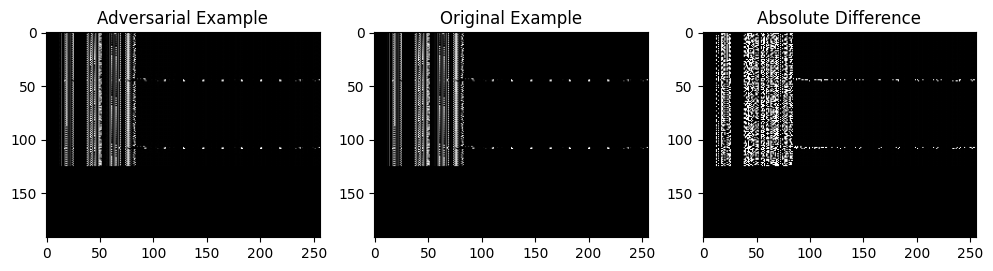

In [ ]:
# plot adv real and abs diff side by side
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(adv_img, cmap="gray")
plt.title("Adversarial Example")
plt.subplot(132)
plt.imshow(real, cmap="gray")
plt.title("Original Example")
plt.subplot(133)
plt.imshow(np.abs(adv_img - real).astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Absolute Difference")
plt.savefig(adv.output_dir / "fgsm" / "adversarial_example_comparison.png")
plt.show()

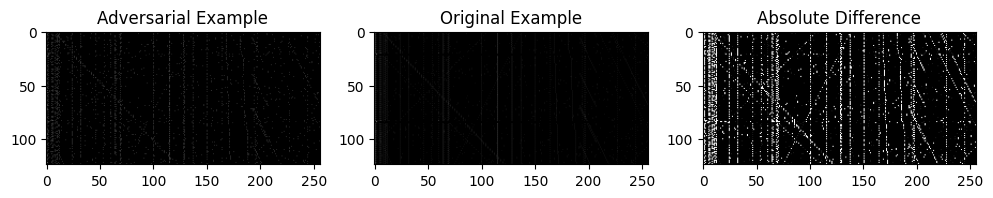

In [2]:
import cv2
from pathlib import Path
import numpy as np

# plot adv real and abs diff side by side
import matplotlib.pyplot as plt

adv_file = Path(
    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\adversarial\normal_normalized\fastgradientmethod_eps_0.1\NORMAL_460_20200515_DNP3_Warm_Restart_Attack_UOWM_DNP3_Dataset_Master_normalized.png"
)
normal_file = (
    Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\session_images"
    )
    / adv_file.name
)
real = cv2.imread(str(normal_file), cv2.IMREAD_GRAYSCALE)
adv_img = cv2.imread(str(adv_file), cv2.IMREAD_GRAYSCALE)[
    : real.shape[0], : real.shape[1]
]
adv_img[real == 0] = 0  # Preserve blank areas

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(adv_img, cmap="gray", vmin=0, vmax=255)
plt.title("Adversarial Example")
plt.subplot(132)
plt.imshow(real, cmap="gray", vmin=0, vmax=255)
plt.title("Original Example")
plt.subplot(133)
plt.imshow(np.abs(adv_img - real).astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Absolute Difference")
# plt.savefig(adv.output_dir / "fgsm" / "adversarial_example_comparison.png")
plt.show()

## Adversarial Blocking: Data

In [25]:
from pydantic import BaseModel, Field


class AdversarialDataPairConfig(BaseModel):
    session_images_dir: Path = Field(
        default=Path(
            r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\session_images"
        ),
        description="Root directory of original images",
    )
    labelled_csv: Path = Field(
        default=Path(
            r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\labelled_sessions.csv"
        ),
        description="CSV file with labelled sessions",
    )
    adversarial_images_dir: list[Path, float] = Field(
        default=[
            (
                Path(
                    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\adversarial\normal\fastgradientmethod_eps_0.1"
                ),
                0.25,
            ),
            (
                Path(
                    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\adversarial\normal\fastgradientmethod_eps_0.01"
                ),
                0.25,
            ),
            (
                Path(
                    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\adversarial\normal\basiciterativemethod_eps_0.1"
                ),
                0.25,
            ),
            (
                Path(
                    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\adversarial\normal\basiciterativemethod_eps_0.01"
                ),
                0.25,
            ),
        ],
        description="List of tuples containing adversarial image directories and their selection rate",
    )
    clean_selection_rate: float = Field(
        default=0.5,
        description="Selection rate for clean images",
    )
    train_ratio: float = Field(
        default=0.8,
        description="Ratio of data to use for training",
    )
    random_seed: int = Field(
        default=42,
        description="Random seed for reproducibility",
    )
    num_pkts: int = Field(
        default=192,
        description="Number of packets to consider for each session (Height)",
    )
    byte_length: int = Field(
        default=256,
        description="Byte length of each packet (Width)",
    )
    max_data: int = Field(
        default=-1,
        description="Maximum number of data points to load. -1 means no limit.",
    )
    is_normalized: bool = Field(
        default=False,
        description="If using normalized images",
    )


from sklearn.model_selection import train_test_split
from ids_expt.core.defs import DataType
import cv2
import torch
import pandas as pd
from loguru import logger
import numpy as np


class AdversarialDataPair:
    def __init__(self, config: AdversarialDataPairConfig = AdversarialDataPairConfig()):
        self.config = config
        self.labelled_csv = config.labelled_csv
        self.clean_selection_rate = config.clean_selection_rate
        self.random_seed = config.random_seed
        self.random_state = np.random.RandomState(self.random_seed)
        self.num_pkts = config.num_pkts
        self.byte_length = config.byte_length
        self.train_ratio = self.config.train_ratio
        self.data_type = None
        self.data_df = None
        self.train_df = None
        self.test_df = None

    def load_data(self):
        data_df = pd.read_csv(self.labelled_csv)

        self.data_df = data_df.copy()
        self.data_df["label"] = self.data_df.flow_label
        # it does notr have file_path col
        if self.config.is_normalized:
            logger.info("Using normalized images for training")
            self.data_df["file_path"] = self.data_df.apply(
                lambda row: self.config.session_images_dir
                / f"{row.session_file_name.replace('.pcap', '_normalized.png')}",
                axis=1,
            )
        else:
            self.data_df["file_path"] = self.data_df.apply(
                lambda row: self.config.session_images_dir
                / f"{row.session_file_name.replace('.pcap', '.png')}",
                axis=1,
            )

        if self.config.max_data > 0:
            logger.info(f"Limiting dataset to {self.config.max_data} samples per class")
            self.data_df = self.data_df.groupby("label").head(self.config.max_data)
        logger.info(
            f"Final dataset size: {len(self.data_df)} entries after applying max_data limit"
        )
        train_df, test_df = train_test_split(
            self.data_df,
            train_size=self.train_ratio,
            stratify=self.data_df["label"],
            random_state=self.config.random_seed,
        )
        self.train_df = train_df.reset_index(drop=True)
        self.test_df = test_df.reset_index(drop=True)
        logger.info(
            f"Split data into {len(self.train_df)} training and {len(self.test_df)} testing samples"
        )
        train_dataset = AdversarialDataPair(self.config)
        train_dataset.data_df = self.train_df
        train_dataset.data_type = DataType.TRAIN

        test_dataset = AdversarialDataPair(self.config)
        test_dataset.data_df = self.test_df
        test_dataset.data_type = DataType.VALIDATION
        logger.info(f"Created datasets: {train_dataset} and {test_dataset}")
        logger.info(
            f"{train_dataset.data_type}: {train_dataset.data_df.label.value_counts()}"
        )
        return train_dataset, test_dataset

    def __len__(self):
        if self.data_df is not None:
            return len(self.data_df)

    def __getitem__(self, idx):
        if self.data_df is not None:
            row = self.data_df.iloc[idx]
        image_path = Path(row["file_path"])
        label = row["label"]
        lbl_string = row.label

        if image_path.exists():
            img = cv2.imread(str(image_path))
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = gray_img.shape
            # check num pkts
            if h < self.config.num_pkts:
                # pad with zeros
                pad_height = self.config.num_pkts - h
                gray_img = cv2.copyMakeBorder(
                    gray_img, 0, pad_height, 0, 0, cv2.BORDER_CONSTANT, value=0
                )
            elif h > self.config.num_pkts:
                gray_img = gray_img[: self.config.num_pkts, :]
            # check byte length but not for normalized bcz normalized has only 256 cols
            if not self.config.is_normalized:
                if w < self.config.byte_length:
                    # pad with zeros
                    pad_width = self.config.byte_length - w
                    gray_img = cv2.copyMakeBorder(
                        gray_img, 0, 0, 0, pad_width, cv2.BORDER_CONSTANT, value=0
                    )
                elif w > self.config.byte_length:
                    gray_img = gray_img[:, : self.config.byte_length]
            gray_img = gray_img / 255
            # above image is the target image now find the input image
            input_img = gray_img.copy()
            if self.config.clean_selection_rate > self.random_state.rand():
                # select original image
                pass
            else:
                # select adversarial image
                adv_roots = [
                    adv_dir for adv_dir, _ in self.config.adversarial_images_dir
                ]
                probabilities = [prob for _, prob in self.config.adversarial_images_dir]

                adv_img_path = self.random_state.choice(adv_roots, p=probabilities)
                adv_img_path = adv_img_path / image_path.name
                if adv_img_path.exists():
                    adv_img = cv2.imread(str(adv_img_path), cv2.IMREAD_GRAYSCALE)
                    if adv_img is not None:
                        input_img = adv_img
                    else:
                        logger.warning(f"Adversarial image {adv_img_path} not found.")
                else:
                    logger.warning(
                        f"Adversarial image path {adv_img_path} does not exist."
                    )
            return input_img, gray_img

        raise IndexError("DataFrame is empty or not loaded.")


class TorchPairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset: AdversarialDataPair):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        gray_img, input_img = self.dataset[idx]
        return (
            torch.tensor(gray_img, dtype=torch.float32).unsqueeze(0),
            torch.tensor(input_img, dtype=torch.float32).unsqueeze(0),
        )

In [26]:
train_ds, test_ds = AdversarialDataPair().load_data()

2025-07-05 18:46:54.088 | INFO     | __main__:load_data:123 - Final dataset size: 40420 entries after applying max_data limit
2025-07-05 18:46:54.149 | INFO     | __main__:load_data:134 - Split data into 32336 training and 8084 testing samples
2025-07-05 18:46:54.150 | INFO     | __main__:load_data:144 - Created datasets: <__main__.AdversarialDataPair object at 0x000001645D01C2F0> and <__main__.AdversarialDataPair object at 0x000001645D01DB20>
2025-07-05 18:46:54.154 | INFO     | __main__:load_data:145 - train: label
NORMAL                 11504
WARM_RESTART            4608
DISABLE_UNSOLICITED     4608
COLD_RESTART            4608
DNP3_ENUMERATE          2704
DNP3_INFO               2673
INIT_DATA                554
STOP_APP                 544
REPLAY                   533
Name: count, dtype: int64


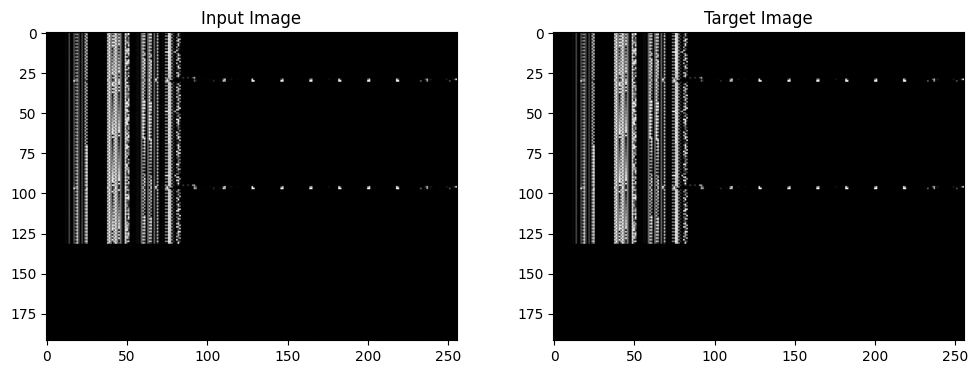

In [34]:
import matplotlib.pyplot as plt

# viz inp and target images
inp, tar = train_ds[0]

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.imshow(inp, cmap="gray")
plt.title("Input Image")
plt.subplot(122)
plt.imshow(tar, cmap="gray")
plt.title("Target Image")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp


class DecoderNoSkip(nn.Module):
    def __init__(self, encoder_channels, decoder_channels):
        super().__init__()
        # The first decoder block should take the encoder's bottleneck output as input
        in_channels = encoder_channels[-1]
        self.blocks = nn.ModuleList()
        for out_channels in decoder_channels:
            self.blocks.append(
                nn.Sequential(
                    nn.Upsample(scale_factor=2, mode="nearest"),
                    nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                    nn.ReLU(inplace=True),
                )
            )
            in_channels = out_channels

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


class UNetAutoencoderNoSkip(nn.Module):
    def __init__(
        self,
        encoder_name="resnet34",
        in_channels=3,
        out_channels=3,
        encoder_weights=None,
    ):
        super().__init__()
        # Get encoder from SMP
        self.encoder = smp.encoders.get_encoder(
            encoder_name, in_channels=in_channels, depth=5, weights=encoder_weights
        )
        encoder_channels = self.encoder.out_channels
        
        decoder_channels = encoder_channels[-2::-1]
        self.decoder = DecoderNoSkip(encoder_channels, decoder_channels)
        self.final_conv = nn.Conv2d(decoder_channels[-1], out_channels, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        x = features[-1]
        x = self.decoder(x)
        x = self.final_conv(x)
        return x


# Example usage:
if __name__ == "__main__":
    model = UNetAutoencoderNoSkip(
        encoder_name="resnet18",
        in_channels=1,
        out_channels=1,
        encoder_weights=None,
    )
    x = torch.randn(2, 1, 128, 128)
    out = model(x)
    print("Input shape:", x.shape)
    print("Output shape:", out.shape)

Input shape: torch.Size([2, 1, 128, 128])
Output shape: torch.Size([2, 1, 128, 128])


In [46]:
train_tds = TorchPairDataset(train_ds)

In [51]:
model(train_tds[0][0].unsqueeze(0))

tensor([[[[-0.3808, -0.3803, -0.3802,  ..., -0.3798, -0.3793, -0.3801],
          [-0.3809, -0.3805, -0.3800,  ..., -0.3795, -0.3794, -0.3800],
          [-0.3810, -0.3806, -0.3802,  ..., -0.3797, -0.3797, -0.3802],
          ...,
          [-0.3810, -0.3806, -0.3800,  ..., -0.3797, -0.3796, -0.3802],
          [-0.3810, -0.3807, -0.3803,  ..., -0.3801, -0.3801, -0.3804],
          [-0.3815, -0.3815, -0.3811,  ..., -0.3812, -0.3812, -0.3810]]]],
       grad_fn=<ConvolutionBackward0>)